# Telecom Churn EDA

I wanted to dig into the IBM Telco dataset to figure out why customers are leaving. The cost of acquiring a new user is always higher than keeping an old one, so figuring out exactly *who* is churning (and what we can actually do about it) is the main goal here.

## 1. Getting the data in

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")
np.random.seed(42)

df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
display(df.head())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Just looking at the top rows, we have some standard demographics (partner, dependents, senior citizen status), the services they're paying for, and their billing setup. The target variable is `Churn` on the far right.

## 2. Cleaning things up

`TotalCharges` loaded in as an object because a few brand-new customers (tenure = 0) have blank strings instead of numbers. I'm going to force those to numeric, which will turn the blanks into nulls, and then fill them with 0 since they haven't actually paid anything yet.

In [2]:
# Check datatypes first
print(df.dtypes[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Force TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_count = df['TotalCharges'].isnull().sum()
print(f"\nMissing after forcing to numeric: {missing_count}")

# Fill the new NaNs with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"Missing now: {df['TotalCharges'].isnull().sum()}")

print(f"Duplicated rows: {df.duplicated().sum()}")

# Map the target variable to 1s and 0s
df['Churn_Label'] = df['Churn']
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

Missing after forcing to numeric: 11
Missing now: 0
Duplicated rows: 0


## 3. Some EDA\n\n### Overall Churn

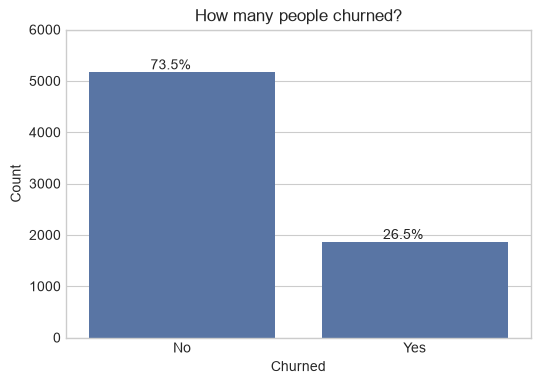

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn_Label', data=df, order=['No', 'Yes'], color='#4c72b0')
plt.title('How many people churned?')
plt.xlabel('Churned')
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    perc = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 50
    ax.annotate(perc, (x, y), ha='center')
plt.ylim(0, 6000)
plt.show()

About 26.5% of people churned last month. That's the baseline we're working with.

### Contracts

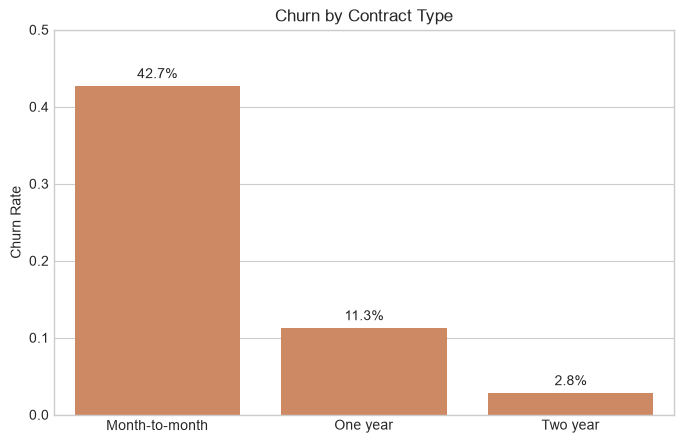

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Contract', y='Churn', data=df, order=['Month-to-month', 'One year', 'Two year'], color='#dd8452', errorbar=None)
plt.title('Churn by Contract Type')
plt.xlabel('')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.5)

for p in ax.patches:
    perc = f'{100 * p.get_height():.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.01
    ax.annotate(perc, (x, y), ha='center')
plt.show()

Month-to-month users are leaving in droves (nearly 43% churn). Unsurprisingly, people locked into two-year contracts almost never leave.

### Tenure and Bills

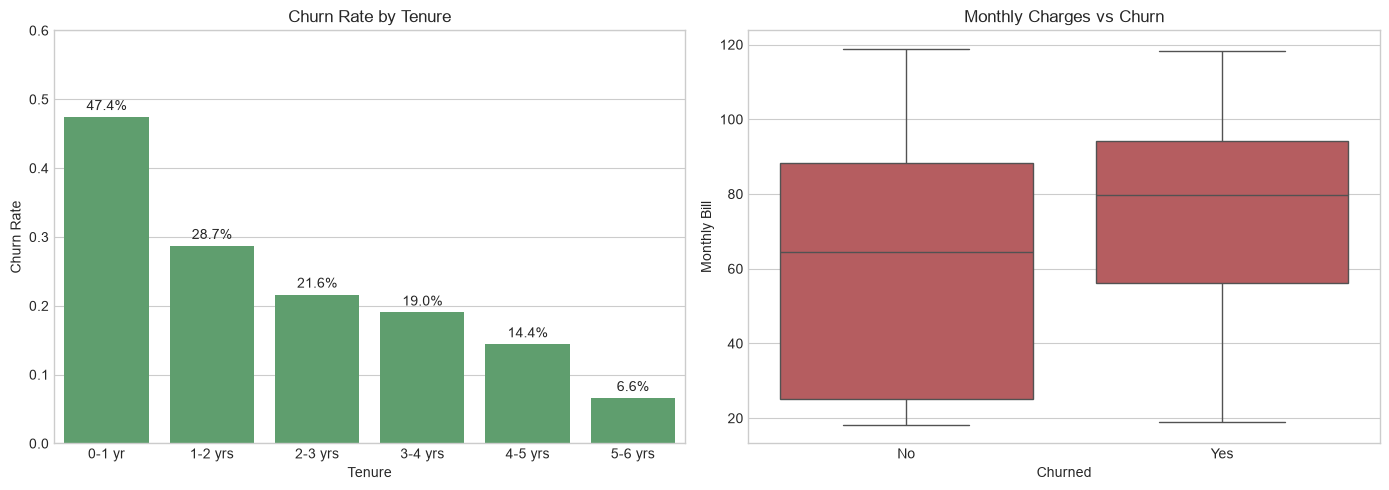

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Tenure bucket
df['Tenure_Bucket'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72], labels=['0-1 yr', '1-2 yrs', '2-3 yrs', '3-4 yrs', '4-5 yrs', '5-6 yrs'])
sns.barplot(x='Tenure_Bucket', y='Churn', data=df, color='#55a868', errorbar=None, ax=ax1)
ax1.set_title('Churn Rate by Tenure')
ax1.set_xlabel('Tenure')
ax1.set_ylabel('Churn Rate')
ax1.set_ylim(0, 0.6)
for p in ax1.patches:
    ax1.annotate(f'{100 * p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01), ha='center')

# Monthly charges
sns.boxplot(x='Churn_Label', y='MonthlyCharges', data=df, order=['No', 'Yes'], color='#c44e52', ax=ax2)
ax2.set_title('Monthly Charges vs Churn')
ax2.set_xlabel('Churned')
ax2.set_ylabel('Monthly Bill')

plt.tight_layout()
plt.show()

Most of the bleeding happens early on—almost half the churn comes from people in their first year. Also, the people leaving tend to have slightly higher monthly bills.

### Demographics & Services

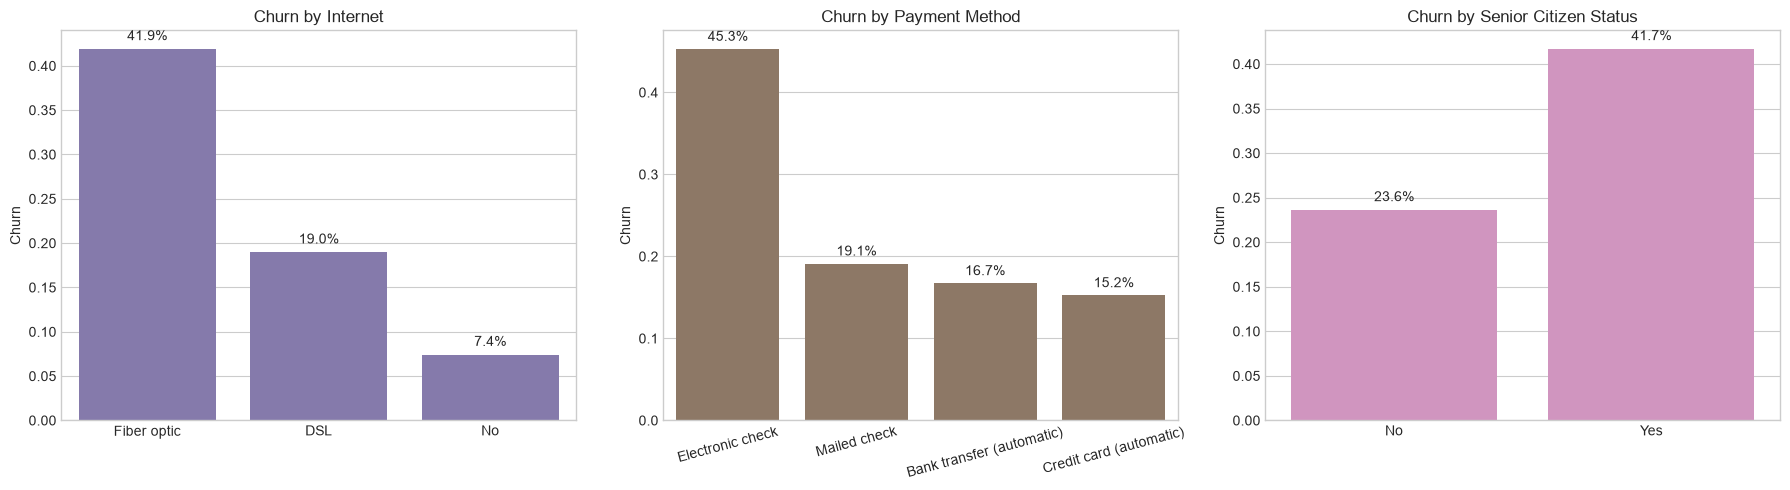

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='InternetService', y='Churn', data=df, order=['Fiber optic', 'DSL', 'No'], color='#8172b3', errorbar=None, ax=axes[0])
axes[0].set_title('Churn by Internet')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{100 * p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01), ha='center')

sns.barplot(x='PaymentMethod', y='Churn', data=df, color='#937860', errorbar=None, ax=axes[1])
axes[1].set_title('Churn by Payment Method')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f'{100 * p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01), ha='center')

df['Senior_Label'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
sns.barplot(x='Senior_Label', y='Churn', data=df, order=['No', 'Yes'], color='#da8bc3', errorbar=None, ax=axes[2])
axes[2].set_title('Churn by Senior Citizen Status')
axes[2].set_xlabel('')
for p in axes[2].patches:
    axes[2].annotate(f'{100 * p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01), ha='center')

plt.tight_layout()
plt.show()

Fiber optic looks like a major issue here, with way higher churn than DSL. Electronic check users and seniors are also churning at elevated rates.

## 4. The real problem

In [7]:
total_churners = df[df['Churn'] == 1].shape[0]
mtm_churners = df[(df['Churn'] == 1) & (df['Contract'] == 'Month-to-month')].shape[0]

mtm_share = (mtm_churners / total_churners) * 100

print(f"Total people who churned: {total_churners}")
print(f"Churners on month-to-month: {mtm_churners}")
print(f"Share: {mtm_share:.1f}%")

Total people who churned: 1869
Churners on month-to-month: 1655
Share: 88.6%


**The big takeaway:** Out of everyone who left, 88.6% were on a month-to-month plan. If we want to fix churn, we literally just have to fix month-to-month retention.

## 5. Quick Baseline Model\n\nI'm throwing together a basic logistic regression just to see how predictable this actually is before doing anything complicated.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

features = df.drop(columns=['customerID', 'Churn', 'Churn_Label', 'Tenure_Bucket', 'Senior_Label'])
X = pd.get_dummies(features, drop_first=True)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

majority_baseline = 1 - y_test.mean()
print(f"Dumb baseline (guessing 'No' for everyone): {majority_baseline * 100:.1f}%\n")

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc * 100:.1f}%")
print(f"ROC-AUC: {auc:.3f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Dumb baseline (guessing 'No' for everyone): 73.5%



Accuracy: 80.5%
ROC-AUC: 0.843

Confusion Matrix:
[[924 111]
 [164 210]]


**How'd it do?**
Accuracy hit around 80.5%, which beats just guessing 'No' (73.5%). The ROC-AUC of 0.843 means it's pretty decent at separating the churners from the stayers.

The obvious catch is that this is just a linear model with default settings, so it's probably missing weird interactions (like how a high bill might push a new customer to leave, but an older customer might not care).

## 6. What should we actually do?

1. **Focus heavily on year one:** Since almost half of the drop-offs happen in the first 12 months, onboarding is probably lacking.
2. **Check the fiber optic product:** A 42% churn rate on fiber is terrible. Either the product is bad, the pricing is wrong, or the competition is just better. Support needs to look into this.
3. **Get people off month-to-month:** Offer a heavy discount or a free add-on if month-to-month users agree to switch to a 1-year contract around their 3rd or 4th month.

**The main priority:**
Just focus on the month-to-month users. They make up 88.6% of the churn. If we can convert a fraction of them to annual plans, the churn rate will plummet.